Download Data...


[*********************100%***********************]  9 of 9 completed



     RESULTS: PORTFOLIO #2 vs S&P 500
                         Portfolio Long/Short  S&P 500
Total Return                          540.42%  111.51%
Annualized Return (CAGR)               66.21%   22.75%
Annualized Volatility                  28.81%   15.00%
Sharpe Ratio (Rf=4)                      2.16     1.25
Maximum Drawdown                      -28.51%  -18.76%

Portfolio Beta #2 vs S&P 500: 0.75


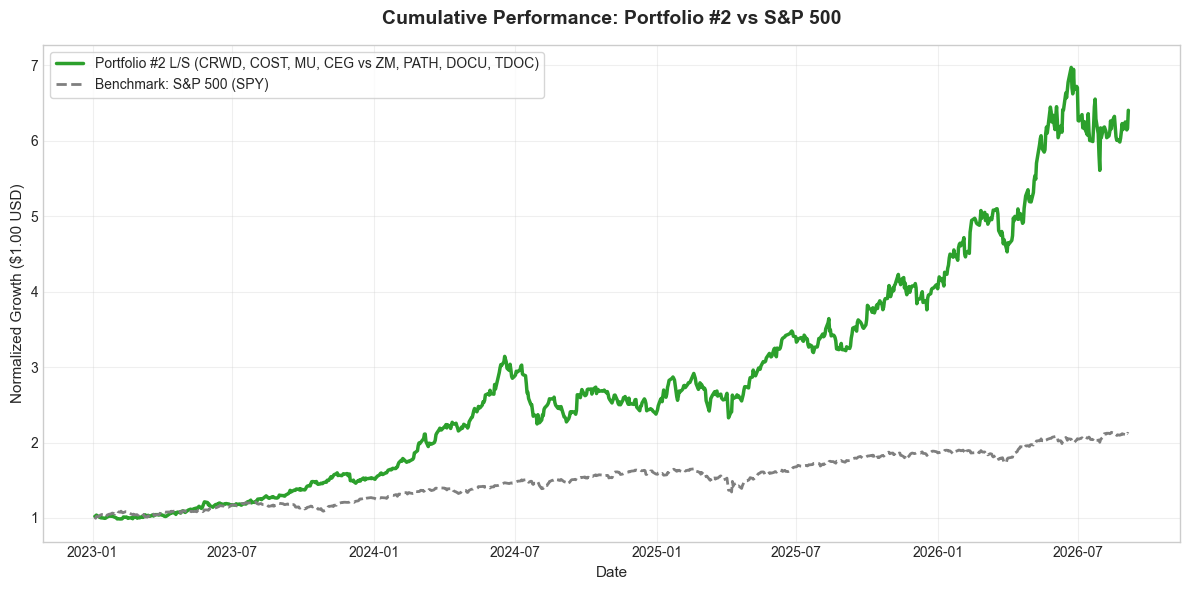

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

long_tickers = ['CRWD', 'COST', 'MU', 'CEG']

short_tickers = ['ZM', 'PATH', 'DOCU', 'TDOC']

benchmark_ticker = 'SPY'

all_tickers = long_tickers + short_tickers + [benchmark_ticker]

weights = {
    'CRWD': 0.25,
    'COST': 0.25,
    'MU': 0.25,
    'CEG': 0.25,
    'ZM': -0.125,
    'PATH': -0.125,
    'DOCU': -0.125,
    'TDOC': -0.125
}

start_date = '2023-01-01'
print("Download Data...")
data = yf.download(all_tickers, start=start_date,auto_adjust=True)['Close']
data = data.dropna()

daily_returns = data.pct_change().dropna()

portfolio_daily_returns = pd.Series(0.0, index = daily_returns.index)

for ticker, weight in weights.items():
    portfolio_daily_returns += daily_returns[ticker] * weight
benchmark_daily_returns = daily_returns[benchmark_ticker]

portfolio_cum_returns = (1 + portfolio_daily_returns).cumprod()
benchmark_cum_returns = (1 + benchmark_daily_returns).cumprod()

def calculate_metrics(returns_series, cum_returns_series, risk_free_rate = 0.04):
    total_return = cum_returns_series.iloc[-1] - 1
    num_days = len(returns_series)
    ann_return = (1 + total_return) ** (252/num_days) - 1 

    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe_ratio = (ann_return - risk_free_rate) / ann_vol

     
    rolling_max = cum_returns_series.cummax()
    drawdown = (cum_returns_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    return {
        'Total Return': f"{total_return * 100:.2f}%",
        'Annualized Return (CAGR)': f"{ann_return * 100:.2f}%",
        'Annualized Volatility': f"{ann_vol * 100:.2f}%",
        'Sharpe Ratio (Rf=4)': f"{sharpe_ratio:.2f}",
        'Maximum Drawdown': f"{max_drawdown * 100:.2f}%"
    }

covariance = np.cov(portfolio_daily_returns, benchmark_daily_returns)[0][1]
benchmark_variance = np.var(benchmark_daily_returns)
portfolio_beta = covariance / benchmark_variance

metrics_df = pd.DataFrame({
    'Portfolio Long/Short': calculate_metrics(portfolio_daily_returns, portfolio_cum_returns),
    'S&P 500': calculate_metrics(benchmark_daily_returns, benchmark_cum_returns)
})

print("\n" + "="*55)
print("     RESULTS: PORTFOLIO #2 vs S&P 500")
print("="*55)
print(metrics_df)
print(f"\nPortfolio Beta #2 vs S&P 500: {portfolio_beta:.2f}")

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.figure(figsize=(12, 6))

plt.plot(portfolio_cum_returns.index, portfolio_cum_returns, 
         label='Portfolio #2 L/S (CRWD, COST, MU, CEG vs ZM, PATH, DOCU, TDOC)', 
         color='#2ca02c', linewidth=2.5) 
plt.plot(benchmark_cum_returns.index, benchmark_cum_returns, 
         label='Benchmark: S&P 500 (SPY)', 
         color='#7f7f7f', linestyle='--', linewidth=2)

plt.title('Cumulative Performance: Portfolio #2 vs S&P 500', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Normalized Growth ($1.00 USD)', fontsize=11)
plt.legend(loc='upper left', fontsize=10, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


 